In [1]:

# =========================================
# 1. Import Required Libraries
# =========================================
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, BatchNormalization, Conv1D, MaxPooling1D, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint




2025-05-02 09:59:52.970148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746179993.150719      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746179993.202790      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# =========================================
# 2. Dataset Loading
# =========================================
dataset_path = "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data"

file_paths = []
emotions = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            if file.endswith(".wav"):
                emotion = file.split("_")[-1].replace(".wav", "")
                if emotion == "ps":
                    emotion = "pleasant_surprise"
                emotions.append(emotion)
                file_paths.append(os.path.join(folder_path, file))

df = pd.DataFrame({"emotion": emotions, "path": file_paths})
print("Sample rows:")
print(df.head())

Sample rows:
  emotion                                               path
0    fear  /kaggle/input/toronto-emotional-speech-set-tes...
1    fear  /kaggle/input/toronto-emotional-speech-set-tes...
2    fear  /kaggle/input/toronto-emotional-speech-set-tes...
3    fear  /kaggle/input/toronto-emotional-speech-set-tes...
4    fear  /kaggle/input/toronto-emotional-speech-set-tes...


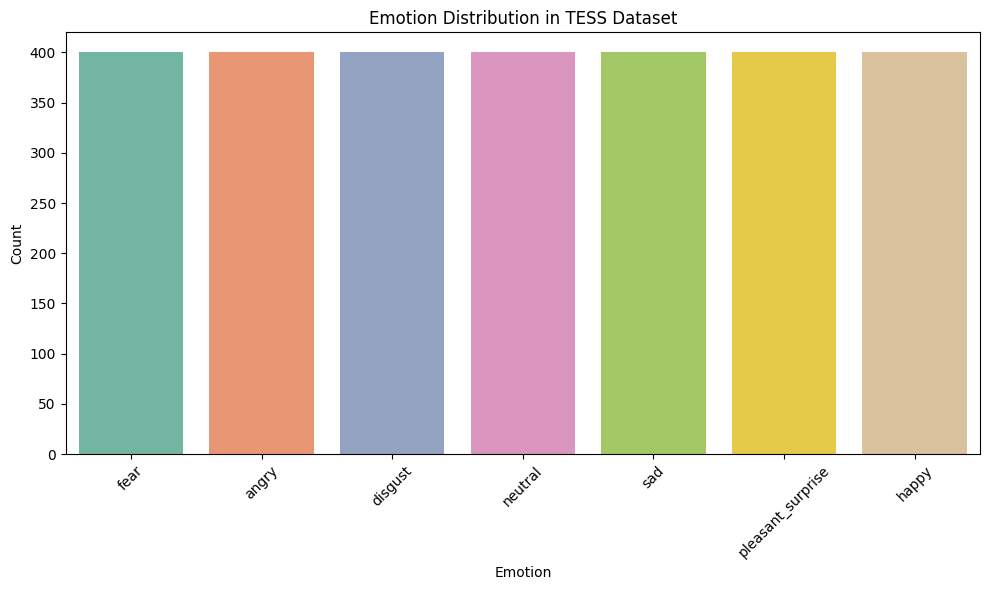

In [7]:
# =========================================
# 2B. Visualize Emotion Distribution
# =========================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(x='emotion', data=df, order=df['emotion'].value_counts().index, palette='Set2')
plt.title('Emotion Distribution in TESS Dataset')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [3]:
# =========================================
# 3. Label Encoding
# =========================================
encoder = LabelEncoder()
df["label"] = encoder.fit_transform(df["emotion"])



In [4]:
# =========================================
# 4. Data Augmentation Functions
# =========================================
def add_noise(data, noise_level=0.005):
    return data + noise_level * np.random.randn(len(data))

def shift_pitch(data, sr, steps=2):
    return librosa.effects.pitch_shift(data, sr=sr, n_steps=steps)

def time_stretch(data, rate=1.1):
    return librosa.effects.time_stretch(data, rate=rate)

In [5]:


# =========================================
# 5. Feature Extraction
# =========================================
sample_rate = 22050
n_mfcc = 40
max_pad_len = 300

X = []
y = []

for i, row in df.iterrows():
    audio, sr = librosa.load(row["path"], sr=sample_rate)
    
    # Apply augmentations
    augmented_audios = [
        audio,
        add_noise(audio),
        shift_pitch(audio, sr),
        time_stretch(audio)
    ]

    for aug_audio in augmented_audios:
        mfcc = librosa.feature.mfcc(y=aug_audio, sr=sr, n_mfcc=n_mfcc)
        mfcc = librosa.util.fix_length(mfcc, size=max_pad_len, axis=1)
        mfcc = mfcc.T  # shape: (time, features)
        X.append(mfcc)
        y.append(row["label"])

X = np.array(X)
y = np.array(y)
print("Extracted features shape:", X.shape)


Extracted features shape: (11200, 300, 40)


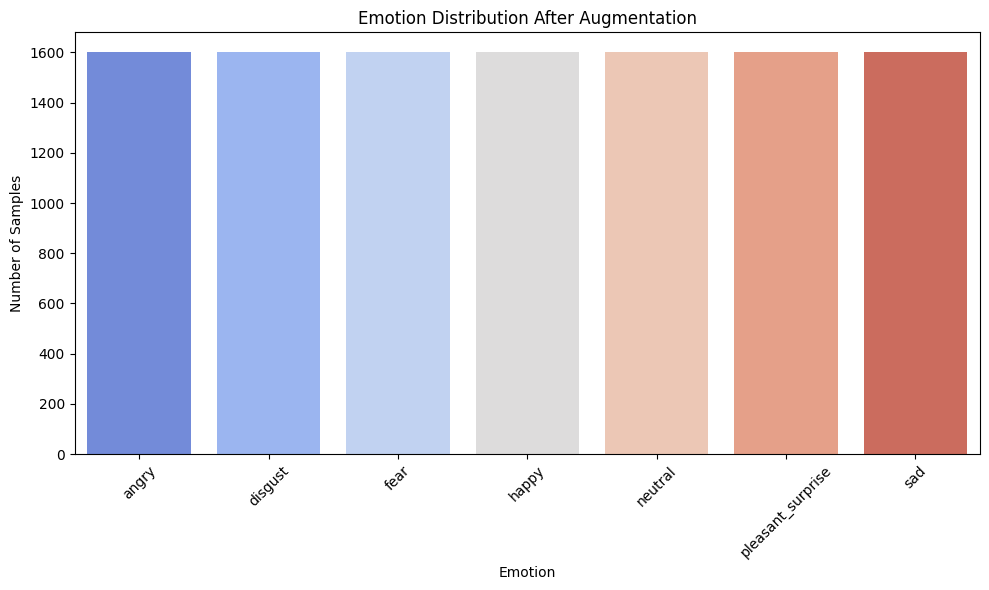

In [11]:
# =========================================
# 5B. Visualize Augmented Label Distribution
# =========================================
unique, counts = np.unique(y, return_counts=True)
emotion_names = encoder.inverse_transform(unique)

plt.figure(figsize=(10, 6))
sns.barplot(x=emotion_names, y=counts, palette='coolwarm')
plt.title('Emotion Distribution After Augmentation')
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [6]:

# =========================================
# 6. Preprocessing Labels
# =========================================
y_cat = to_categorical(y)
print("Categorical labels shape:", y_cat.shape)


Categorical labels shape: (11200, 7)


In [8]:
# =========================================
# 7. Train-Validation-Test Split (60% train, 20% val, 20% test)
# =========================================
# Step 1: Split off the test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

# Step 2: Split the remaining 80% into train (60%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
# 0.25 x 80% = 20%

# Print shapes to confirm
print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (6720, 300, 40), Validation: (2240, 300, 40), Test: (2240, 300, 40)


In [13]:

# =========================================
# 8. Model Architecture (CNN + BiLSTM)
# =========================================
model = Sequential()
model.add(Conv1D(128, kernel_size=5, activation='relu', input_shape=(X.shape[1], X.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Dropout(0.3))
model.add(Bidirectional(LSTM(64)))
model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(y_cat.shape[1], activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 296, 128)            │          25,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 296, 128)            │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 148, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 148, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 146, 256)            │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 146, 256)            │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 73, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 73, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 73, 256)             │         394,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 73, 256)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 128)                 │         164,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 7)                   │             903 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 701,831 (2.68 MB)

 Trainable params: 701,063 (2.67 MB)

 Non-trainable params: 768 (3.00 KB)

In [14]:

# =========================================
# 9. Training Setup (with Early Stopping)
# =========================================
from tensorflow.keras.callbacks import EarlyStopping

checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6)
early_stopper = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, lr_reducer, early_stopper]
)


Epoch 1/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.6253 - loss: 0.9829 - val_accuracy: 0.9920 - val_loss: 0.0306 - learning_rate: 0.0010
Epoch 2/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9868 - loss: 0.0516 - val_accuracy: 0.9946 - val_loss: 0.0201 - learning_rate: 0.0010
Epoch 3/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9868 - loss: 0.0442 - val_accuracy: 0.9969 - val_loss: 0.0176 - learning_rate: 0.0010
Epoch 4/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9932 - loss: 0.0247 - val_accuracy: 0.9906 - val_loss: 0.0368 - learning_rate: 0.0010
Epoch 5/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9930 - loss: 0.0298 - val_accuracy: 0.9955 - val_loss: 0.0184 - learning_rate: 0.0010
Epoch 6/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9950 - loss: 0.0154 - val_accuracy: 0.9982 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 7/50
210/210 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.9944 - loss: 0

In [15]:

# =========================================
# 10. Evaluation
# =========================================
model.load_weights("best_model.keras")
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=encoder.classes_))
print("Confusion Matrix:")
print(confusion_matrix(y_true_labels, y_pred_labels))

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Classification Report:
                   precision    recall  f1-score   support

            angry       1.00      1.00      1.00       320
          disgust       1.00      1.00      1.00       320
             fear       1.00      1.00      1.00       320
            happy       1.00      1.00      1.00       320
          neutral       1.00      1.00      1.00       320
pleasant_surprise       1.00      0.99      1.00       320
              sad       1.00      1.00      1.00       320

         accuracy                           1.00      2240
        macro avg       1.00      1.00      1.00      2240
     weighted avg       1.00      1.00      1.00      2240

Confusion Matrix:
[[320   0   0   0   0   0   0]
 [  0 320   0   0   0   0   0]
 [  0   0 320   0   0   0   0]
 [  0   0   0 320   0   0   0]
 [  0   0   0   0 320   0   0]
 [  1   0   0   1   0 318   0]
 [  0   0   0   0   0   0 320]]


In [16]:
checkpoint = ModelCheckpoint("best_model.keras", monitor='val_accuracy', save_best_only=True)


In [17]:
from tensorflow.keras.models import load_model

# Load the best model
model = load_model("best_model.keras")


In [18]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Convert one-hot predictions and true labels to integers
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=encoder.classes_))

print("Confusion Matrix:")
print(confusion_matrix(y_true_labels, y_pred_labels))


Classification Report:
                   precision    recall  f1-score   support

            angry       1.00      1.00      1.00       320
          disgust       1.00      1.00      1.00       320
             fear       1.00      1.00      1.00       320
            happy       1.00      1.00      1.00       320
          neutral       1.00      1.00      1.00       320
pleasant_surprise       1.00      0.99      1.00       320
              sad       1.00      1.00      1.00       320

         accuracy                           1.00      2240
        macro avg       1.00      1.00      1.00      2240
     weighted avg       1.00      1.00      1.00      2240

Confusion Matrix:
[[320   0   0   0   0   0   0]
 [  0 320   0   0   0   0   0]
 [  0   0 320   0   0   0   0]
 [  0   0   0 320   0   0   0]
 [  0   0   0   0 320   0   0]
 [  1   0   0   1   0 318   0]
 [  0   0   0   0   0   0 320]]


In [21]:
import random

def predict_emotion_from_folder(folder_path, num_samples=10):
    # List all .wav files in the given folder and its subfolders
    all_wavs = []
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".wav"):
                all_wavs.append(os.path.join(root, file))
    
    # Randomly sample 10 files
    selected_files = random.sample(all_wavs, min(num_samples, len(all_wavs)))

    print(f"\nPredicting {len(selected_files)} samples from: {folder_path}\n")

    for path in selected_files:
        try:
            audio, sr = librosa.load(path, sr=sample_rate)
            mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
            mfcc = librosa.util.fix_length(mfcc, size=max_pad_len, axis=1)
            mfcc = mfcc.T[np.newaxis, ...]  # shape: (1, time, features)

            prediction = model.predict(mfcc)
            label_index = np.argmax(prediction)
            emotion = encoder.inverse_transform([label_index])[0]

            print(f"{os.path.basename(path)} → Predicted Emotion: {emotion}")
        except Exception as e:
            print(f"Failed to process {path}: {e}")


In [22]:
predict_emotion_from_folder(
    "/kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data",
    num_samples=10
)



Predicting 10 samples from: /kaggle/input/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
OAF_shall_ps.wav → Predicted Emotion: pleasant_surprise
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
OAF_pearl_sad.wav → Predicted Emotion: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
OAF_room_happy.wav → Predicted Emotion: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
OAF_chief_fear.wav → Predicted Emotion: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
YAF_ring_happy.wav → Predicted Emotion: happy
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
OAF_sell_disgust.wav → Predicted Emotion: disgust
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
OAF_hate_sad.wav → Predicted Emotion: sad
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
YAF_team_angry.wav → Predicted Emotion: angry
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
YAF_page_fear.wav → Predicted Emotion: fear
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
YAF_check_sad.wav → Predicted Emotion: sad
